In [1]:
# ── CELDA 1: Importaciones ─────────────────────────────────────

import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scripts.database import engine

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from sklearn.utils import resample

sns.set_theme(style="whitegrid")

print("✅ Librerías cargadas correctamente")

✅ Conexión engine lista
✅ Librerías cargadas correctamente


In [2]:
# ── CELDA 2: Extracción de datos ───────────────────────────────

QUERY = """
SELECT
    height,
    weight,
    base_experience
FROM pokemon
ORDER BY id
"""

df = pd.read_sql(QUERY, engine)

df.rename(columns={
    'height': 'Height',
    'weight': 'Weight',
    'base_experience': 'Base_Experience'
}, inplace=True)

print("✅ Datos cargados")
print(df.head())

✅ Datos cargados
   Height  Weight  Base_Experience
0       7      69               64
1      10     130              142
2      20    1000              236
3       6      85               62
4      11     190              142


In [3]:
# ── CELDA 3: Variable objetivo binaria ─────────────────────────

df['Strong'] = (df['Base_Experience'] >= 100).astype(int)

print(df.head())

   Height  Weight  Base_Experience  Strong
0       7      69               64       0
1      10     130              142       1
2      20    1000              236       1
3       6      85               62       0
4      11     190              142       1


Strong
1    11
0     9
Name: count, dtype: int64


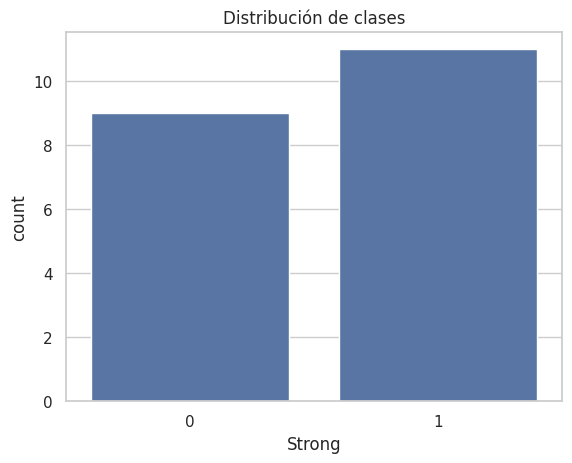

In [4]:
# ── CELDA 4: Balance de clases ─────────────────────────────────

print(df['Strong'].value_counts())

sns.countplot(data=df, x='Strong')

plt.title("Distribución de clases")
plt.show()

In [5]:
# ── CELDA 5: Oversampling ──────────────────────────────────────

df_majority = df[df['Strong'] == 0]
df_minority = df[df['Strong'] == 1]

df_minority_oversampled = resample(
    df_minority,
    replace=True,
    n_samples=len(df_majority),
    random_state=42
)

df_balanced = pd.concat([
    df_majority,
    df_minority_oversampled
])

print(df_balanced['Strong'].value_counts())

Strong
0    9
1    9
Name: count, dtype: int64


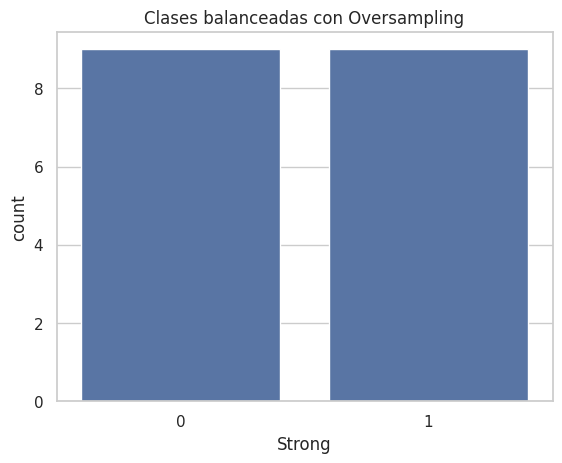

In [6]:
# ── CELDA 6: Visualización balanceada ──────────────────────────

sns.countplot(data=df_balanced, x='Strong')

plt.title("Clases balanceadas con Oversampling")

plt.show()

In [7]:
# ── CELDA 7: Variables predictoras y objetivo ──────────────────

X = df_balanced[['Height', 'Weight']]
y = df_balanced['Strong']

print(X.head())

    Height  Weight
0        7      69
3        6      85
6        5      90
9        3      29
10       7      99


In [8]:
# ── CELDA 8: División train/test ───────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (14, 2)
Test: (4, 2)


In [9]:
# ── CELDA 9: GridSearchCV ──────────────────────────────────────

parametros = {
    'max_depth': [2, 3, 4, 5, 6],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    parametros,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Mejores parámetros:")
print(grid.best_params_)

Mejores parámetros:
{'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [10]:
# ── CELDA 10: Modelo final ─────────────────────────────────────

modelo = grid.best_estimator_

modelo.fit(X_train, y_train)

print("✅ Modelo entrenado")

✅ Modelo entrenado


In [11]:
# ── CELDA 11: Predicciones ─────────────────────────────────────

y_pred = modelo.predict(X_test)

y_prob = modelo.predict_proba(X_test)[:,1]

In [12]:
# ── CELDA 12: Métricas ─────────────────────────────────────────

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc = roc_auc_score(y_test, y_prob)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC AUC  :", roc)

print("\nReporte de Clasificación\n")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

Accuracy : 0.75
Precision: 1.0
Recall   : 0.5
F1 Score : 0.6666666666666666
ROC AUC  : 0.75

Reporte de Clasificación

              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      0.50      0.67         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4



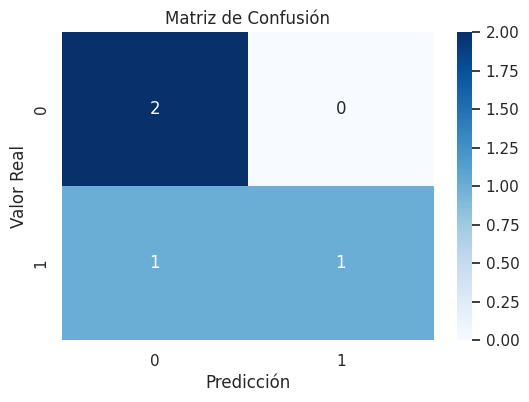

In [15]:
# ── CELDA 13: Matriz de confusión ──────────────────────────────

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['0', '1'],
    yticklabels=['0', '1']
)

plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.title("Matriz de Confusión")

plt.show()

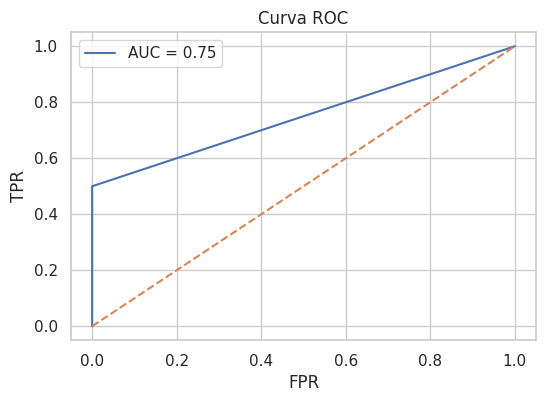

In [16]:
# ── CELDA 14: Curva ROC ────────────────────────────────────────

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr, label=f"AUC = {roc:.2f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("FPR")
plt.ylabel("TPR")

plt.title("Curva ROC")

plt.legend()

plt.show()

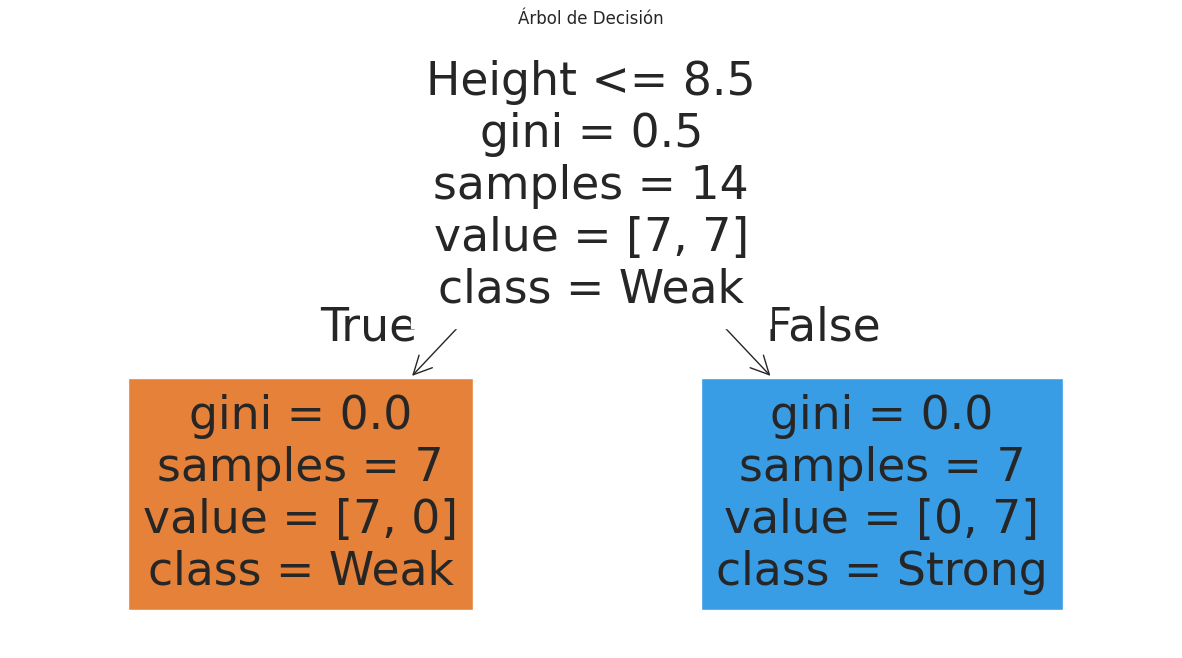

In [17]:
# ── CELDA 15: Visualización árbol ──────────────────────────────

plt.figure(figsize=(15,8))

plot_tree(
    modelo,
    feature_names=X.columns,
    class_names=['Weak', 'Strong'],
    filled=True
)

plt.title("Árbol de Decisión")

plt.show()

In [18]:
# ── CELDA 16: Conclusiones ─────────────────────────────────────

print("""
CONCLUSIONES

1. Se aplicó clasificación binaria usando Árbol de Decisión.

2. Se realizó balanceo de clases mediante oversampling con resample.

3. Se utilizaron métricas como Accuracy, Precision,
Recall, F1-Score y ROC-AUC para evaluar el modelo.

4. Se implementó GridSearchCV para optimizar
los hiperparámetros del modelo.

5. El modelo logró identificar correctamente
Pokémon fuertes y débiles.
""")


CONCLUSIONES

1. Se aplicó clasificación binaria usando Árbol de Decisión.

2. Se realizó balanceo de clases mediante oversampling con resample.

3. Se utilizaron métricas como Accuracy, Precision,
Recall, F1-Score y ROC-AUC para evaluar el modelo.

4. Se implementó GridSearchCV para optimizar
los hiperparámetros del modelo.

5. El modelo logró identificar correctamente
Pokémon fuertes y débiles.

